# 🧠 Tea Leaf Disease Classification with Transfer Learning

This notebook presents a deep learning pipeline for classifying tea leaf diseases using the TeaLeafBD dataset.  
We apply transfer learning with **EfficientNetB0**, using data augmentation and validation splitting to build a image classification model.

**Dataset Overview:**
- Total images: 5,276
- Number of classes: 7 (6 diseases + 1 healthy leaf)
- Format: JPG images, organized in training and test folders
- Source: Mendeley Data - Tea Leaf Disease Detection

**Environment:**
- Framework: TensorFlow + Keras
- Hardware: CPU/GPU (runtime adaptable)

In [7]:
# 📦 Install libraries silently (only required if using Google Colab or similar environments)
%pip install -q tensorflow matplotlib pandas

# -------------------------------
# 🔧 Core Python & Data Handling
# -------------------------------
import os                    # File and directory operations
import numpy as np           # Numerical computations and arrays
import pandas as pd          # Tabular data manipulation (for submission.csv)
from collections import Counter  # To inspect class distribution

# -------------------------------
# 📊 Visualization
# -------------------------------
import matplotlib.pyplot as plt  # For plotting accuracy/loss and data inspection

# -------------------------------
# 🤖 TensorFlow / Keras
# -------------------------------
import tensorflow as tf  # Main deep learning library (Keras backend)

# Image preprocessing & real-time data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Pretrained model for transfer learning
from tensorflow.keras.applications import ResNet50

# Model architecture definition
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Training utilities: regularization and dynamic learning rate adjustment
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# -------------------------------
# ⚖️ Handling Class Imbalance
# -------------------------------
from sklearn.utils.class_weight import compute_class_weight  # Automatically compute weights for imbalanced datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📂 Data Preparation & Augmentation

This section handles the loading, preprocessing, and augmentation of the dataset.

- **Training Set**: Loaded from the `train/` folder, with subfolders representing each class (7 categories).
- **Validation Set**: Automatically split from the training set using `validation_split=0.2` (i.e., 80% training, 20% validation).
- **Test Set**: Contains unlabeled `.jpg` images in the `test/` folder. These are loaded without labels to generate final predictions.

We apply data augmentation techniques such as rotation, zoom, and horizontal flip to improve model generalization, along with pixel normalization (`rescale=1./255`).

The `ImageDataGenerator` class is used to create generators that will feed batches of images to the model during training and evaluation.

In [8]:
# Get the current working directory (assumes the notebook is located at the root of the 'data' folder)
base_dir = os.getcwd()

# Define absolute paths to the training and test directories
train_dir = os.path.join(base_dir, 'data', 'train')
test_dir = os.path.join(base_dir, 'data', 'test')

# -------------------------
# Data Augmentation & Preprocessing
# -------------------------

# Define an ImageDataGenerator for training with real-time data augmentation and validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0,1]
    rotation_range=20,           # Randomly rotate images by up to 20 degrees
    zoom_range=0.2,              # Random zoom within the range [1.0 - 1.2]
    horizontal_flip=True,        # Random horizontal flipping
    validation_split=0.2         # Reserve 20% of data for validation
)

# Training data generator (80% of the training set)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),      # Resize all images to 224x224
    batch_size=32,
    class_mode='categorical',    # Use categorical labels (one-hot encoded)
    subset='training',           # This subset is used for training
    shuffle=True                 # Shuffle the data for better generalization
)

# Validation data generator (20% of the training set)
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',         # This subset is used for validation
    shuffle=False                # Do not shuffle to preserve order for evaluation
)

# -------------------------
# Test Data Preprocessing
# -------------------------

# Define a separate generator for test data (unlabeled)
# All test images are expected to be directly inside the "test" folder without subdirectories
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    directory=os.path.join(base_dir, 'data'),  # Points to the parent of 'test'
    classes=['test'],                          # Treats 'test/' as a single pseudo-class folder
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,                           # No labels provided for test images
    shuffle=False                              # Keep filenames in order for submission.csv
)

Found 3821 images belonging to 7 classes.
Found 951 images belonging to 7 classes.
Found 504 images belonging to 1 classes.


## 🧠 Model Architecture – Transfer Learning with EfficientNetB0

In this section, we build a convolutional neural network using **transfer learning**.  
We use **EfficientNetB0**, a lightweight and high-performing model pretrained on ImageNet.

- We exclude the top classification layer (`include_top=False`) and attach a custom head.
- A **GlobalAveragePooling2D** layer reduces spatial dimensions.
- A **Dropout** layer (50%) is added for regularization.
- A final **Dense softmax** layer with 7 output nodes is used for classification into tea leaf disease categories.

To begin with, all layers of the base model are **frozen** (non-trainable), so we only train the custom classification head.

In [9]:
# Load the base EfficientNetB0 model without the top classifier
# 'weights=imagenet' loads pretrained ImageNet weights
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Add custom classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)      # Reduce spatial dimensions
x = Dropout(0.5)(x)                  # Apply dropout to prevent overfitting
predictions = Dense(7, activation='softmax')(x)  # Output layer for 7 classes

# Construct the complete model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze all base model layers (initial phase: training only the classification head)
for layer in base_model.layers:
    layer.trainable = False

# Compile the model with a standard categorical crossentropy loss
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## ⚖️ Class Weighting to Handle Dataset Imbalance

The TeaLeafBD dataset exhibits a noticeable **class imbalance**, with some disease categories significantly under-represented.  
If not addressed, this imbalance can lead the model to **favor majority classes**, resulting in poor generalization and biased predictions.

To mitigate this, we apply **class weighting**, a technique that adjusts the training loss function to:

- Assign **higher penalties to errors** made on under-represented classes
- **Reduce bias** toward majority classes
- Encourage the model to **learn all classes fairly**

The weights are computed using `sklearn.utils.class_weight.compute_class_weight` in `'balanced'` mode, which automatically assigns weights inversely proportional to class frequencies.

In [10]:
print(Counter(train_generator.classes))

# Compute class weights to address dataset imbalance
# 'balanced' mode assigns higher weights to under-represented classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),  # The set of class indices
    y=train_generator.classes                    # The actual class labels in the training data
)

# Convert weights to dictionary format expected by model.fit()
class_weights_dict = dict(enumerate(class_weights))

# Display the computed weights for each class index
print("Class Weights:", class_weights_dict)

Counter({5: 948, 2: 763, 6: 659, 3: 422, 1: 373, 4: 345, 0: 311})
Class Weights: {0: 1.7551676619200736, 1: 1.4634239754883187, 2: 0.7154090994195843, 3: 1.2935003385240351, 4: 1.5821946169772256, 5: 0.5757986738999398, 6: 0.8283112941686538}


## 🔄 Phased Fine-Tuning Strategy

To improve model generalization while preventing overfitting, we apply **phased fine-tuning**:

- **Phase 1:** Only the top classification head is trained; the backbone is frozen.
- **Phase 2:** The last 50 layers of the pretrained backbone are unfrozen and trained with a low learning rate.
- At the end of each phase, we **save the best model** using `ModelCheckpoint`.
- Before starting the next phase, we **load the best weights** from the previous one.

This progressive training helps adapt pretrained features gradually to our tea leaf disease dataset.

In [5]:
#----------------------------------
#------------ Phase 1
#----------------------------------

# Freeze all layers of the base (pretrained) model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model for head training with a relatively higher learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # Start with higher LR for fast convergence
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Save the best model based on validation loss
checkpoint_phase1 = ModelCheckpoint(
    'best_model_phase1.keras',   # File to save the model weights
    monitor='val_loss',          # Metric to monitor
    save_best_only=True,         # Save only if val_loss improves
    verbose=1
)

# Train only the top classification layers
history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),  # Stop early if no improvement
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),  # Reduce LR on plateau
        checkpoint_phase1  # Save best model
    ],
    class_weight=class_weights_dict  # Handle class imbalance
)

c:\Users\cfernandez.ext\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1671 - loss: 2.5505
Epoch 1: val_loss improved from inf to 1.96097, saving model to best_model_phase1.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 317s 3s/step - accuracy: 0.1671 - loss: 2.5493 - val_accuracy: 0.0578 - val_loss: 1.9610 - learning_rate: 1.0000e-04
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1526 - loss: 2.1996
Epoch 2: val_loss improved from 1.96097 to 1.95665, saving model to best_model_phase1.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 305s 3s/step - accuracy: 0.1525 - loss: 2.1999 - val_accuracy: 0.0862 - val_loss: 1.9567 - learning_rate: 1.0000e-04
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1537 - loss: 2.1575
Epoch 3: val_loss improved from 1.95665 to 1.95241, saving model to best_model_phase1.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.1537 - loss: 2.1575 - val_accuracy: 0.0810 - val_loss: 1.9524 - learning_rate: 1.0000e-04
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━

In [6]:
#----------------------------------
#------------ Phase 2
#----------------------------------

# Reload the best model from Phase 1 before fine-tuning deeper layers
model.load_weights('best_model_phase1.keras')

# Unfreeze the last 50 layers of the base model (allow them to be trained)
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Recompile the model with a lower learning rate for gentle fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Smaller LR to avoid damaging pretrained weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Save the best model again during Phase 2
checkpoint_phase2 = ModelCheckpoint(
    'best_model_phase2.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the model with deeper layers now unfrozen
history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
        checkpoint_phase2
    ],
    class_weight=class_weights_dict
)

c:\Users\cfernandez.ext\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\cfernandez.ext\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


KeyboardInterrupt: 

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load MobileNetV2 without the classification head
base_model_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom head
x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)

model_mobilenet = Model(inputs=base_model_mobilenet.input, outputs=predictions)

# Freeze base model layers initially
for layer in base_model_mobilenet.layers:
    layer.trainable = False

# Compile the model
model_mobilenet.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint_mobilenet = ModelCheckpoint('best_model_mobilenet.keras', monitor='val_loss', save_best_only=True, verbose=1)

# Train head only
history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
        checkpoint_mobilenet
    ],
    class_weight=class_weights_dict
)

# Fine-tune last 30 layers (optional Phase 2 for MobileNetV2)
for layer in base_model_mobilenet.layers[-30:]:
    layer.trainable = True

model_mobilenet.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune the unfrozen layers
history_mobilenet_ft = model_mobilenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ],
    class_weight=class_weights_dict
)


c:\Users\cfernandez.ext\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1471 - loss: 2.6267
Epoch 1: val_loss improved from inf to 1.88481, saving model to best_model_mobilenet.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.1473 - loss: 2.6255 - val_accuracy: 0.2387 - val_loss: 1.8848 - learning_rate: 1.0000e-04
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2274 - loss: 2.2336
Epoch 2: val_loss improved from 1.88481 to 1.63210, saving model to best_model_mobilenet.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.2274 - loss: 2.2333 - val_accuracy: 0.4006 - val_loss: 1.6321 - learning_rate: 1.0000e-04
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2702 - loss: 2.0005
Epoch 3: val_loss improved from 1.63210 to 1.46958, saving model to best_model_mobilenet.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.2704 - loss: 1.9999 - val_accuracy: 0.4627 - val_loss: 1.4696 - learning_rate: 1.0000e-04
Epoch 4/10
120/120 ━━━━━━━

In [ ]:
# Data Augmentation avancée (boostée)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,       # + fort
    zoom_range=0.3,          # gros zoom
    shear_range=0.2,         # déformation
    horizontal_flip=True,
    vertical_flip=True,      # flip vertical important pour les feuilles
    brightness_range=[0.7, 1.3],  # variations fortes de lumière
    validation_split=0.2
)

# Training & Validation generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


import tensorflow_addons as tfa
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Load best weights from previous phase
model_mobilenet.load_weights('best_model_mobilenet.keras')

# Unfreeze ALL layers for Phase 3 fine-tuning
for layer in model_mobilenet.layers:
    layer.trainable = True

# Compile with Focal Loss and very small learning rate
model_mobilenet.compile(
    optimizer=Adam(1e-6),
    loss=tfa.losses.SigmoidFocalCrossEntropy(gamma=2.0),
    metrics=['accuracy']
)


# Callbacks to stabilize fine-tuning
checkpoint_phase3 = ModelCheckpoint(
    'best_model_mobilenet_phase3.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    checkpoint_phase3
]

# Fine-tune entire MobileNetV2 model
history_phase3 = model_mobilenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=fine_tune_callbacks,
    class_weight=class_weights_dict
)

## 📤 Prediction & Submission

With the fine-tuned model trained, we now generate predictions on the **unlabeled test set**.

The results are mapped back to class labels and saved in the required `submission.csv` format:

In [7]:
# Predict using the fine-tuned model
preds = model.predict(test_generator, verbose=1)
pred_classes = np.argmax(preds, axis=1)

# Map predicted class indices back to class names
label_map = {v: k for k, v in train_generator.class_indices.items()}
filenames = [os.path.basename(f) for f in test_generator.filenames]
submission = pd.DataFrame({
    'filename': filenames,
    'class': [label_map[k] for k in pred_classes]
})

# Export the predictions to a CSV file
submission.to_csv('submission.csv', index=False)

504/504 ━━━━━━━━━━━━━━━━━━━━ 49s 93ms/step


## 📈 Training Progress Visualization

To monitor the model’s learning process, we visualize training and validation performance over each epoch.

This helps assess:
- Convergence speed
- Overfitting or underfitting
- Improvement brought by fine-tuning

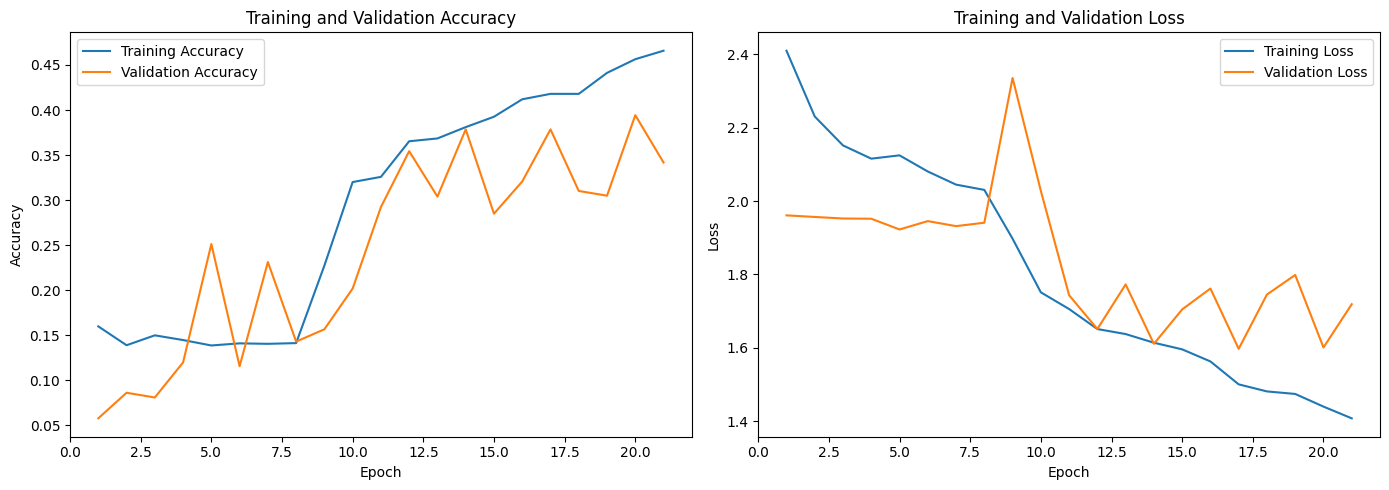

In [8]:
# Function to plot training and validation curves for multiple training phases
def plot_training_history(history_phase1, history_phase2=None, title_suffix=''):
    # Extract metrics from phase 1
    acc = history_phase1.history['accuracy']
    val_acc = history_phase1.history['val_accuracy']
    loss = history_phase1.history['loss']
    val_loss = history_phase1.history['val_loss']

    # If there is a second phase, append its metrics
    if history_phase2:
        acc += history_phase2.history['accuracy']
        val_acc += history_phase2.history['val_accuracy']
        loss += history_phase2.history['loss']
        val_loss += history_phase2.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    # Plot Accuracy
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy' + title_suffix)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss' + title_suffix)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the function with your actual training histories
plot_training_history(history_phase1, history_phase2)